# CSCI 544 Group 17 - Disaster Tweet Classification
## Step 1: Data & Preprocessing | Step 2: TF-IDF Baselines
---
**Members:** Yike Yang, Huaiyu Guo, Kailin Hu, Kunxian Wang, Weinan Zhou

This notebook covers:
1. **Data loading** from Kaggle
2. **EDA** (Exploratory Data Analysis)
3. **Preprocessing pipeline** (shared by all team members)
4. **TF-IDF Baselines** (Logistic Regression, Linear SVM, Naive Bayes)
5. **Results summary table**

---
## 0. Setup & Kaggle Data Download
This notebook and its input are placed in a shared google drive folder. Therefore need to connect(mount) it here. The data processed after will also be saved 'locally' in this folder.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# input directory
DATA_DIR = '/content/drive/MyDrive/CS544-Group17-Project/input/'

---
## 1. Data Loading & Initial Inspection
Load train and test sets, check data shape column names, missing values, classification(disaster or not). Also identify duplicated entries with conflicting labels.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Read, Load data, identify its shape
train_df = pd.read_csv(f'{DATA_DIR}train.csv')
test_df = pd.read_csv(f'{DATA_DIR}test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print(f"\nTrain columns: {list(train_df.columns)}")
print(f"Test columns:  {list(test_df.columns)}")
train_df.head()

Train shape: (7613, 5)
Test shape:  (3263, 4)

Train columns: ['id', 'keyword', 'location', 'text', 'target']
Test columns:  ['id', 'keyword', 'location', 'text']


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [ ]:
# Basic stats
# Check missing values
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
for col in train_df.columns:
    missing = train_df[col].isnull().sum()
    pct = missing / len(train_df) * 100
    print(f"  {col:12s}: {missing:5d} missing ({pct:.1f}%)")

# Classify how many are disasters and how many are not
print(f"\n{'=' * 50}")
print("CLASS DISTRIBUTION")
print("=" * 50)
counts = train_df['target'].value_counts()
for label, count in counts.items():
    print(f"  target={label}: {count} ({count/len(train_df)*100:.1f}%)")

print(f"\n{'=' * 50}")
print("KEYWORD STATS")
print("=" * 50)
print(f"  Unique keywords: {train_df['keyword'].nunique()}")
print(f"  Coverage: {train_df['keyword'].notna().sum()} / {len(train_df)}")

MISSING VALUES
  id          :     0 missing (0.0%)
  keyword     :    61 missing (0.8%)
  location    :  2533 missing (33.3%)
  text        :     0 missing (0.0%)
  target      :     0 missing (0.0%)

CLASS DISTRIBUTION
  target=0: 4342 (57.0%)
  target=1: 3271 (43.0%)

KEYWORD STATS
  Unique keywords: 221
  Coverage: 7552 / 7613


In [ ]:
# Duplicate check
dup_text = train_df.duplicated(subset=['text'], keep=False)
print(f"Duplicate tweets (by text): {dup_text.sum()}")

# Show duplicates with conflicting labels
dup_df = train_df[dup_text].sort_values('text')
conflicting = dup_df.groupby('text')['target'].nunique()
conflicting_texts = conflicting[conflicting > 1].index
print(f"Duplicates with CONFLICTING labels: {len(conflicting_texts)}")

if len(conflicting_texts) > 0:
    print("\nExamples of conflicting labels:")
    for t in list(conflicting_texts)[:3]:
        subset = train_df[train_df['text'] == t][['text', 'keyword', 'target']]
        print(subset.to_string(index=False))
        print()

Duplicate tweets (by text): 179
Duplicates with CONFLICTING labels: 18

Examples of conflicting labels:
                                                                                                                                      text  keyword  target
#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect hellfire       0
#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect hellfire       0
#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect hellfire       1

                                                                                                                 text   keyword  target
#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption hazardous       1

---
## 2. Exploratory Data Analysis (EDA)
Help us to understand the data's trend better through visuallization on classification, length and word count for tweets.
<br> Note that these visuallization will NOT be included in the training process.

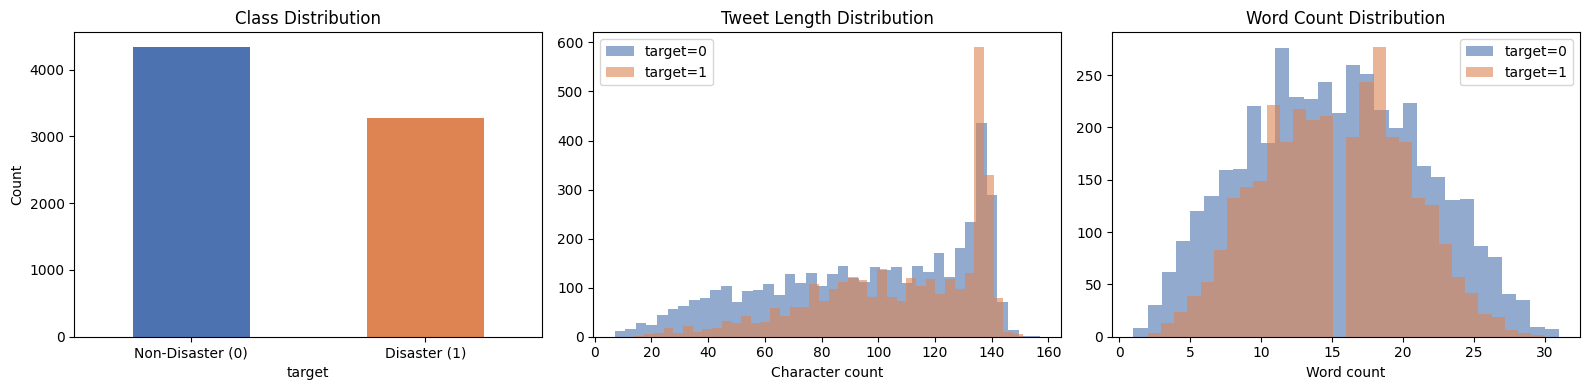

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 2a. Class distribution
train_df['target'].value_counts().plot.bar(ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Non-Disaster (0)', 'Disaster (1)'], rotation=0)
axes[0].set_ylabel('Count')

# 2b. Tweet length distribution
train_df['text_len'] = train_df['text'].str.len()
for label, color in [(0, '#4C72B0'), (1, '#DD8452')]:
    subset = train_df[train_df['target'] == label]
    axes[1].hist(subset['text_len'], bins=40, alpha=0.6, color=color,
                 label=f'target={label}')
axes[1].set_title('Tweet Length Distribution')
axes[1].set_xlabel('Character count')
axes[1].legend()

# 2c. Word count distribution
train_df['word_count'] = train_df['text'].str.split().str.len()
for label, color in [(0, '#4C72B0'), (1, '#DD8452')]:
    subset = train_df[train_df['target'] == label]
    axes[2].hist(subset['word_count'], bins=30, alpha=0.6, color=color,
                 label=f'target={label}')
axes[2].set_title('Word Count Distribution')
axes[2].set_xlabel('Word count')
axes[2].legend()

plt.tight_layout()
plt.show()

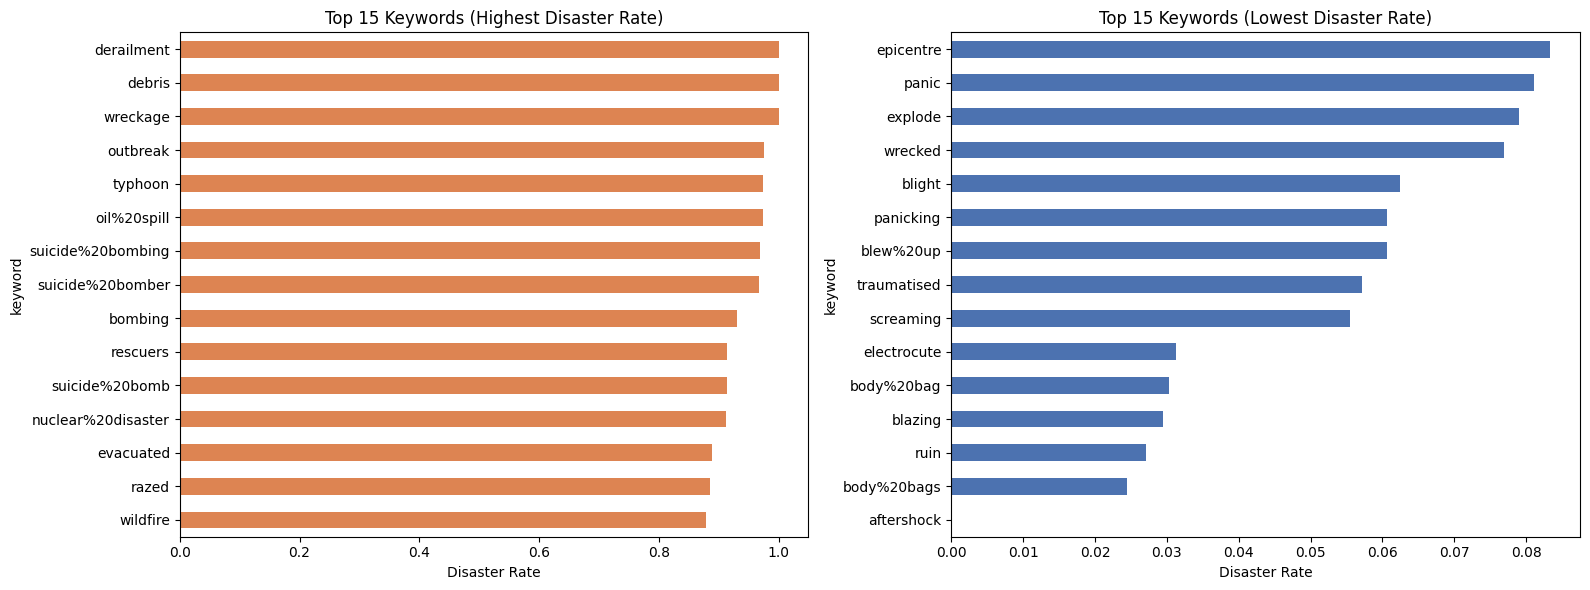

In [ ]:
# Top keywords by disaster rate
kw_stats = (train_df[train_df['keyword'].notna()]
            .groupby('keyword')['target']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'disaster_rate', 'count': 'n'})
            .sort_values('disaster_rate', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top disaster keywords
top_disaster = kw_stats[kw_stats['n'] >= 10].head(15)
top_disaster['disaster_rate'].plot.barh(ax=axes[0], color='#DD8452')
axes[0].set_title('Top 15 Keywords (Highest Disaster Rate)')
axes[0].set_xlabel('Disaster Rate')
axes[0].invert_yaxis()

# Top non-disaster keywords
top_nondisaster = kw_stats[kw_stats['n'] >= 10].tail(15)
top_nondisaster['disaster_rate'].plot.barh(ax=axes[1], color='#4C72B0')
axes[1].set_title('Top 15 Keywords (Lowest Disaster Rate)')
axes[1].set_xlabel('Disaster Rate')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Preprocessing Pipeline

Defines the **shared preprocessing functions** that all subsequent steps will use.

Also handles metadata feature engineering, resolves duplicate tweets with conflicting labels, and **saves the processed data to Google Drive for team-wide access.**

Two preprocessing versions are created:

- `preprocess_for_tfidf()` — aggressive cleaning for classical ML: lowercasing, hashtag-to-word conversion, punctuation and number removal, stopword removal, and lemmatization (e.g., "fires" → "fire").

- `preprocess_for_transformer()` — light cleaning for BERT/BERTweet: only removes URLs and @mentions, preserving casing, punctuation, and word forms for the model's own tokenizer to handle.

In [ ]:
import re
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
tweet_tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

In [ ]:
def clean_text_base(text):
    """Base cleaning shared by all pipelines."""
    if pd.isna(text):
        return ''
    text = str(text)
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove HTML entities
    text = re.sub(r'&amp;|&lt;|&gt;|&quot;', ' ', text)
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    # Remove non-ASCII
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def split_hashtag(text):
    """Split camelCase hashtags: #ForestFire -> forest fire"""
    def _split(match):
        tag = match.group(1)
        # Split on camelCase boundaries
        words = re.sub(r'([a-z])([A-Z])', r'\1 \2', tag)
        # Split on number boundaries
        words = re.sub(r'([a-zA-Z])(\d)', r'\1 \2', words)
        return words.lower()
    return re.sub(r'#(\w+)', _split, text)


def preprocess_for_tfidf(text):
    """Aggressive cleaning for TF-IDF + classical ML."""
    text = clean_text_base(text)
    text = split_hashtag(text)
    # Remove remaining punctuation and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    # Tokenize
    tokens = tweet_tokenizer.tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)


def preprocess_for_transformer(text):
    """Light cleaning for BERT / BERTweet.
    Preserves casing, punctuation, and structure."""
    text = clean_text_base(text)
    # Only split hashtags, keep everything else
    text = split_hashtag(text)
    return text

In [ ]:
# Apply preprocessing
print("Applying preprocessing...")

# For TF-IDF baselines
train_df['text_clean'] = train_df['text'].apply(preprocess_for_tfidf)
test_df['text_clean'] = test_df['text'].apply(preprocess_for_tfidf)

# For transformers (Person 3 & 4 will use this)
train_df['text_transformer'] = train_df['text'].apply(preprocess_for_transformer)
test_df['text_transformer'] = test_df['text'].apply(preprocess_for_transformer)

# Metadata features
# Other than tweet's text, Kaggle also provides two keys: keyword & location
# Keyword is like an email's title; location is user manually input location
# Both of these extra keys can have noises, such as irrelavent keyword or 'my couch' as location
# Therefore need to handle them expliclity.
train_df['keyword_clean'] = train_df['keyword'].fillna('').str.replace('%20', ' ')
test_df['keyword_clean'] = test_df['keyword'].fillna('').str.replace('%20', ' ')

train_df['has_keyword'] = train_df['keyword'].notna().astype(int)
train_df['has_location'] = train_df['location'].notna().astype(int)
test_df['has_keyword'] = test_df['keyword'].notna().astype(int)
test_df['has_location'] = test_df['location'].notna().astype(int)

print("Done!")
print(f"\nSample preprocessed tweets:")
for i in range(3):
    print(f"\n  Original:    {train_df['text'].iloc[i]}")
    print(f"  TF-IDF:      {train_df['text_clean'].iloc[i]}")
    print(f"  Transformer: {train_df['text_transformer'].iloc[i]}")

Applying preprocessing...
Done!

Sample preprocessed tweets:

  Original:    Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
  TF-IDF:      deed reason earthquake may allah forgive u
  Transformer: Our Deeds are the Reason of this earthquake May ALLAH Forgive us all

  Original:    Forest fire near La Ronge Sask. Canada
  TF-IDF:      forest fire near la ronge sask canada
  Transformer: Forest fire near La Ronge Sask. Canada

  Original:    All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
  TF-IDF:      resident asked shelter place notified officer evacuation shelter place order expected
  Transformer: All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected


In [ ]:
# Handle duplicates: keep majority label for conflicting duplicates
def resolve_duplicates(df):
    """For duplicate tweets with conflicting labels, keep majority vote."""
    # Group by text, take majority label
    majority = df.groupby('text')['target'].agg(lambda x: x.mode()[0]).reset_index()
    majority.columns = ['text', 'target_resolved']

    # Drop duplicates, keep first
    df_dedup = df.drop_duplicates(subset=['text'], keep='first').copy()
    df_dedup = df_dedup.merge(majority, on='text', how='left')
    df_dedup['target'] = df_dedup['target_resolved']
    df_dedup = df_dedup.drop(columns=['target_resolved'])

    return df_dedup

train_dedup = resolve_duplicates(train_df)
print(f"Before dedup: {len(train_df)} rows")
print(f"After dedup:  {len(train_dedup)} rows")
print(f"Removed:      {len(train_df) - len(train_dedup)} duplicates")

Before dedup: 7613 rows
After dedup:  7503 rows
Removed:      110 duplicates


### Save preprocessed data (shared with team via Google Drive)
Again, since we are using shared Google folder, we need to save it there.

In [ ]:
# Save to CSV for team sharing
import os
os.makedirs('processed', exist_ok=True)

# Create the directory if it doesn't exist
os.makedirs('/content/drive/MyDrive/CS544-Group17-Project/data', exist_ok=True)
train_dedup.to_csv('/content/drive/MyDrive/CS544-Group17-Project/data/train_processed.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/CS544-Group17-Project/data/test_processed.csv', index=False)
print("Saved processed data to Google Drive.")

Saved processed data to Google Drive.


---
## 4. TF-IDF Baseline Models
Use TF-IDF featrures upon these models:
1. Logistic Regression
2. Linear SVM
3. Multinomial Naive Bayes

Analyze each model's F1, precision, recall, and accuracy through 5-fold cross validation.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import time

In [ ]:
# Use deduplicated data
X_text = train_dedup['text_clean'].values
y = train_dedup['target'].values

print(f"Training samples: {len(X_text)}")
print(f"Class distribution: 0={sum(y==0)}, 1={sum(y==1)}")

Training samples: 7503
Class distribution: 0=4312, 1=3191


In [ ]:
# Define TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),    # unigrams + bigrams
    min_df=2,
    max_df=0.95,
    sublinear_tf=True       # apply log normalization
)

# Define models
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, solver='liblinear', random_state=42
    ),
    'Linear SVM': LinearSVC(
        C=1.0, max_iter=2000, random_state=42
    ),
    'Multinomial NB': MultinomialNB(
        alpha=1.0
    )
}

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['f1', 'precision', 'recall', 'accuracy']

In [ ]:
# Run cross-validation for all models
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print(f"{'='*50}")

    pipeline = Pipeline([
        ('tfidf', tfidf),
        ('clf', model)
    ])

    start = time.time()
    cv_results = cross_validate(
        pipeline, X_text, y,
        cv=cv, scoring=scoring,
        return_train_score=False
    )
    elapsed = time.time() - start

    results[name] = {
        'F1':        cv_results['test_f1'].mean(),
        'F1_std':    cv_results['test_f1'].std(),
        'Precision': cv_results['test_precision'].mean(),
        'Recall':    cv_results['test_recall'].mean(),
        'Accuracy':  cv_results['test_accuracy'].mean(),
        'Time (s)':  elapsed
    }

    print(f"  F1:        {results[name]['F1']:.4f} (+/- {results[name]['F1_std']:.4f})")
    print(f"  Precision: {results[name]['Precision']:.4f}")
    print(f"  Recall:    {results[name]['Recall']:.4f}")
    print(f"  Accuracy:  {results[name]['Accuracy']:.4f}")
    print(f"  Time:      {elapsed:.2f}s")


Training: Logistic Regression
  F1:        0.7484 (+/- 0.0126)
  Precision: 0.8302
  Recall:    0.6816
  Accuracy:  0.8051
  Time:      2.24s

Training: Linear SVM
  F1:        0.7359 (+/- 0.0155)
  Precision: 0.7590
  Recall:    0.7145
  Accuracy:  0.7818
  Time:      2.46s

Training: Multinomial NB
  F1:        0.7335 (+/- 0.0116)
  Precision: 0.8632
  Recall:    0.6380
  Accuracy:  0.8029
  Time:      1.45s


In [ ]:
# Results summary table
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
print("\n" + "=" * 70)
print("BASELINE RESULTS SUMMARY (5-Fold Stratified CV)")
print("=" * 70)
print(results_df.to_string())
print()

# Highlight best
best_model = results_df['F1'].idxmax()
print(f"Best baseline: {best_model} (F1 = {results_df.loc[best_model, 'F1']:.4f})")


BASELINE RESULTS SUMMARY (5-Fold Stratified CV)
                         F1  F1_std  Precision  Recall  Accuracy  Time (s)
Logistic Regression  0.7484  0.0126     0.8302  0.6816    0.8051    2.2433
Linear SVM           0.7359  0.0155     0.7590  0.7145    0.7818    2.4602
Multinomial NB       0.7335  0.0116     0.8632  0.6380    0.8029    1.4474

Best baseline: Logistic Regression (F1 = 0.7484)


## 5. Confusion Matrix & Error Analysis

This section performs a detailed qualitative analysis on the best baseline model (Logistic Regression) using a single 80/20 train/validation split to obtain per-sample predictions.

Four analyses are conducted:

- **Confusion Matrix** — visualizes the distribution of TP, FP, TN, and FN, revealing whether the model is more conservative (missing real disasters) or aggressive (more false alarms).

- **FP / FN Examples** — prints the actual tweet text of misclassified samples, showing what kinds of tweets fool the model (e.g., metaphorical language like "my heart is on fire" triggers false positives).

- **Top Feature Coefficients** — extracts the 20 highest and lowest weighted TF-IDF features from the LR model, exposing the model's decision logic: it relies on keyword matching (e.g., "earthquake" → disaster, "love" → non-disaster), which explains why it fails on figurative language.

In [ ]:
from sklearn.model_selection import train_test_split

# Single train/val split for detailed analysis
X_train, X_val, y_train, y_val = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# Train best baseline on split
best_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000, ngram_range=(1, 2),
        min_df=2, max_df=0.95, sublinear_tf=True
    )),
    ('clf', LogisticRegression(C=1.0, max_iter=1000, solver='liblinear', random_state=42))
])

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_val)

print(classification_report(y_val, y_pred, target_names=['Non-Disaster', 'Disaster']))

              precision    recall  f1-score   support

Non-Disaster       0.79      0.91      0.84       863
    Disaster       0.84      0.67      0.75       638

    accuracy                           0.81      1501
   macro avg       0.82      0.79      0.80      1501
weighted avg       0.81      0.81      0.80      1501



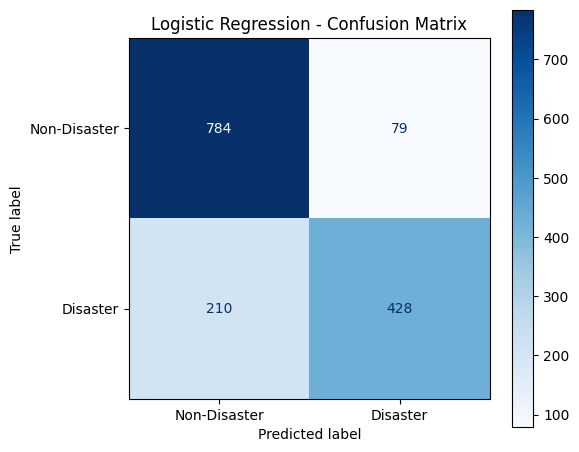

In [ ]:
# Confusion matrix visualization
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred,
    display_labels=['Non-Disaster', 'Disaster'],
    cmap='Blues', ax=ax
)
ax.set_title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Error analysis: inspect misclassified tweets
val_df = train_dedup.iloc[train_test_split(
    range(len(train_dedup)), test_size=0.2, random_state=42,
    stratify=train_dedup['target']
)[1]].copy()
val_df['predicted'] = y_pred
val_df['correct'] = (val_df['target'] == val_df['predicted'])

# False Positives: predicted disaster but actually not
fp = val_df[(val_df['predicted'] == 1) & (val_df['target'] == 0)]
print(f"\nFALSE POSITIVES ({len(fp)} total) - Top examples:")
print("-" * 60)
for _, row in fp.head(5).iterrows():
    print(f"  [{row['keyword_clean']:15s}] {row['text'][:100]}")

# False Negatives: predicted non-disaster but actually disaster
fn = val_df[(val_df['predicted'] == 0) & (val_df['target'] == 1)]
print(f"\nFALSE NEGATIVES ({len(fn)} total) - Top examples:")
print("-" * 60)
for _, row in fn.head(5).iterrows():
    print(f"  [{row['keyword_clean']:15s}] {row['text'][:100]}")


FALSE POSITIVES (79 total) - Top examples:
------------------------------------------------------------
  [hostage        ] You will be held hostage by a radical group.
  [terrorism      ] http://t.co/EQjCpWILVn: Articles In Saudi Press Reject Russian Initiative For Regional Alliance With
  [collapse       ] #ROH3 #JFB #TFB #alrasyid448ItuRasya Correction: Tent Collapse Story http://t.co/iZJToojzKp #US ROH3
  [wild fires     ] They should just have load shedding permanently and we will all just live like we in the wild and ha
  [cyclone        ] HIS MAJESTY EMPEROR SALMAN KHAN'S UNSTOPPABLE CYCLONE OF ENTERTAINMENT HUMANITY
BAJRANGI BHAIJAAN CR

FALSE NEGATIVES (210 total) - Top examples:
------------------------------------------------------------
  [drown          ] I can't drown my demons they know how to swim
  [annihilation   ] World Annihilation vs Self Transformation http://t.co/pyehwodWun Aliens Attack to Exterminate Humans
  [cyclone        ] GREAT CONDITION Easton Cyclone So

In [ ]:
# Top TF-IDF features for each class
feature_names = best_pipeline.named_steps['tfidf'].get_feature_names_out()
coefs = best_pipeline.named_steps['clf'].coef_[0]

top_k = 20
top_disaster_idx = np.argsort(coefs)[-top_k:][::-1]
top_nondisaster_idx = np.argsort(coefs)[:top_k]

print(f"\nTop {top_k} features -> DISASTER:")
for i in top_disaster_idx:
    print(f"  {feature_names[i]:25s} (coef: {coefs[i]:.4f})")

print(f"\nTop {top_k} features -> NON-DISASTER:")
for i in top_nondisaster_idx:
    print(f"  {feature_names[i]:25s} (coef: {coefs[i]:.4f})")


Top 20 features -> DISASTER:
  fire                      (coef: 3.7794)
  hiroshima                 (coef: 3.2836)
  wildfire                  (coef: 2.7925)
  california                (coef: 2.6504)
  bombing                   (coef: 2.4759)
  earthquake                (coef: 2.3920)
  flood                     (coef: 2.3262)
  storm                     (coef: 2.2450)
  train                     (coef: 2.1385)
  killed                    (coef: 2.0637)
  crash                     (coef: 1.9911)
  suicide                   (coef: 1.8586)
  near                      (coef: 1.8482)
  news                      (coef: 1.8395)
  disaster                  (coef: 1.8338)
  japan                     (coef: 1.7783)
  explosion                 (coef: 1.7726)
  typhoon                   (coef: 1.7648)
  massacre                  (coef: 1.7274)
  pm                        (coef: 1.7213)

Top 20 features -> NON-DISASTER:
  im                        (coef: -2.1964)
  let                       (coe

## 6. Generate Kaggle Submission

This section retrains the best baseline model (Logistic Regression) on the **full** training set (all 7,503 samples, not just 80%) and generates predictions on the 3,263 unlabeled test tweets.

If we are to join the Kaggle competition, use the output `submission_baseline.csv` in data folder.

This section's out put is **NOT included** in our report.

In [ ]:
# Train on ALL training data, predict on test set
final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000, ngram_range=(1, 2),
        min_df=2, max_df=0.95, sublinear_tf=True
    )),
    ('clf', LogisticRegression(C=1.0, max_iter=1000, solver='liblinear', random_state=42))
])

final_pipeline.fit(X_text, y)

X_test = test_df['text_clean'].values
test_preds = final_pipeline.predict(X_test)

# Create submission
submission = pd.DataFrame({
    'id': test_df['id'],
    'target': test_preds
})
submission.to_csv('submission_baseline.csv', index=False)
print(f"Submission saved! Shape: {submission.shape}")
print(f"Predicted distribution: 0={sum(test_preds==0)}, 1={sum(test_preds==1)}")
print(f"\nSubmit to: https://www.kaggle.com/c/nlp-getting-started/submit")

Submission saved! Shape: (3263, 2)
Predicted distribution: 0=2155, 1=1108

Submit to: https://www.kaggle.com/c/nlp-getting-started/submit


## 7. Summary

This section summarizes the full progress of Step 1 and Step 2, outlines the next steps for Step 3, and documents how to use the generated files.

**What has been completed (Step 1 & Step 2):**
- Loaded and inspected the Kaggle dataset (7,613 train / 3,263 test tweets)
- Performed exploratory data analysis on class distribution, tweet length, and keyword-disaster correlation
- Built two preprocessing pipelines (`text_clean` for TF-IDF, `text_transformer` for Transformers)
- Engineered metadata features (`keyword_clean`, `has_keyword`, `has_location`)
- Resolved 110 duplicate tweets with conflicting labels via majority vote (7,613 → 7,503 samples)
- Trained and evaluated three TF-IDF baselines with 5-fold stratified CV (best: Logistic Regression, F1 = 0.7484)
- Conducted error analysis identifying figurative language as the primary failure mode
- Generated a baseline Kaggle submission file

**What needs to be done next (Step 3):**
- Fine-tune DistilBERT, RoBERTa, and BERTweet on the preprocessed data
- Run metadata ablation experiments (text only vs. text + keyword vs. text + keyword + location)
- Compare all transformer results against the baselines established here
- Explore ensemble strategies and threshold tuning to further improve F1

**How to use the generated files:**
- `data/train_processed.csv` and `data/test_processed.csv` are stored on Google Drive and contain all original and engineered columns
- Use the `text_transformer` column as input for all transformer fine-tuning
- Use `keyword_clean`, `has_keyword`, and `has_location` columns for metadata ablation experiments
- Use the `text_clean` column if additional TF-IDF experiments are needed

In [ ]:
# Final results for team reference
print("\n" + "=" * 70)
print("COPY THIS TABLE INTO YOUR TEAM REPORT")
print("=" * 70)
print(f"{'Model':<25s} {'F1':>8s} {'Prec':>8s} {'Recall':>8s} {'Acc':>8s}")
print("-" * 60)
for name, r in results.items():
    print(f"{name:<25s} {r['F1']:8.4f} {r['Precision']:8.4f} {r['Recall']:8.4f} {r['Accuracy']:8.4f}")
print("-" * 60)


COPY THIS TABLE INTO YOUR TEAM REPORT
Model                           F1     Prec   Recall      Acc
------------------------------------------------------------
Logistic Regression         0.7484   0.8302   0.6816   0.8051
Linear SVM                  0.7359   0.7590   0.7145   0.7818
Multinomial NB              0.7335   0.8632   0.6380   0.8029
------------------------------------------------------------
